In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from scipy.stats import t
import plot_utils as pu

In [2]:
pu.apply_plot_style()

In [3]:
PROJECT_ROOT = (Path(__vsc_ipynb_file__).parents[1] / "scripts/train_pos_control")
# RUNS
DISTANCE_CONTROL_2B = PROJECT_ROOT / "runs/2B_DistanceControl"
DISTANCE_CONTROL_3B = PROJECT_ROOT / "runs/3B_DistanceControl"
DISTANCE_CONTROL_4B = PROJECT_ROOT / "runs/4B_DistanceControl"

METRIC_DIR = PROJECT_ROOT / "metrics"

In [4]:
def list_tb_run_dirs(log_dir):
    return sorted({
        p.parent
        for p in Path(log_dir).rglob("events.out.tfevents.*")
    })

In [5]:
def list_metrics(metric_dir):
    return sorted(Path(metric_dir).iterdir())

In [6]:
def list_run_and_data(logs, metrics, matched_only=True):
    rows = []

    metrics_by_stem = {
        Path(metric).stem: Path(metric)
        for metric in metrics
    }

    for log in logs:
        log = Path(log)
        run_name = log.name

        metric_path = metrics_by_stem.get(run_name)
        if matched_only and metric_path is None:
            continue

        rows.append({
            "run": run_name,
            "tb_log": log,
            "stat_file": metric_path,
            "has_stat": metric_path is not None,
        })

    return pd.DataFrame(rows)

In [7]:
def _parse_hparams_from_event_accumulator(
    ea,
    tag: str = "hyperparameters/text_summary",
):
    """
    Hparam tábla kiszedése egy már betöltött EventAccumulatorból.
    Nem tölt be újra semmit.
    """

    hparams = {}

    tags = ea.Tags()

    if "tensors" not in tags:
        return hparams

    if tag not in tags["tensors"]:
        return hparams

    events = ea.Tensors(tag)

    if not events:
        return hparams

    text = events[-1].tensor_proto.string_val[0].decode("utf-8")

    for line in text.splitlines():
        line = line.strip()

        if not line.startswith("|"):
            continue

        clean_line = line.replace(" ", "").lower()

        if clean_line in {"|param|value|", "|-|-|"}:
            continue

        parts = [p.strip() for p in line.strip("|").split("|")]

        if len(parts) == 2:
            key, value = parts
            hparams[key] = value

    return hparams


def _read_scalars_from_event_accumulator(
    ea,
    run_id,
    hparams=None,
):
    if hparams is None:
        hparams = {}

    rows = []
    for tag in ea.Tags().get("scalars", []):
        for event in ea.Scalars(tag):
            row = {     
                "run_id": run_id,
                "tag": tag,
                "step": event.step,
                "wall_time": event.wall_time,
                "value": event.value,
            }

            row.update(**hparams)
            rows.append(row)

    return pd.DataFrame(rows)

In [8]:
def read_all_logs(df):
    extracted_hparams_list = []
    dfs = []
    for idx, row in df.iterrows():
        tb = str(row['tb_log'])
        run = str(row['run'])
        hparams = {}

        try:
            ea = EventAccumulator(tb)
            ea.Reload()
            hparams = _parse_hparams_from_event_accumulator(ea)
            log = _read_scalars_from_event_accumulator(ea, run_id=run, hparams=hparams)
            dfs.append(log)

        except Exception as e:
            print(f"Hiba a következő log feldolgozásakor: {tb}. Hiba: {e}")

        extracted_hparams_list.append(hparams)

    hparams_df = pd.DataFrame(extracted_hparams_list, index=df.index)

    return pd.concat([df, hparams_df], axis=1), pd.concat(dfs, ignore_index=True)


In [9]:
def add_stats(df, ci:float=0.95):
    extracted_stats_list = []

    for idx, row in df.iterrows():
        csv_path = str(row['stat_file'])
        stats = {
            'success_rate': np.nan,
            'timeout_rate': np.nan,
            'failure_rate': np.nan,
            'success_ep_len_mean': np.nan,
            'success_ep_len_std': np.nan,
            'success_ep_return_mean': np.nan,
            'success_ep_return_std': np.nan,
            'ep_len_mean' : np.nan,
            'ep_len_std'  : np.nan,
            'ep_len_ci'   : np.nan,
            'ep_return_mean' : np.nan,
            'ep_return_std'  : np.nan,
            'ep_return_ci' : np.nan
        }

        try:
            # 1. Beolvassuk a futási CSV-t
            data = pd.read_csv(csv_path)
            total_episodes = len(data)
            
            if total_episodes == 0:
                extracted_stats_list.append(stats)
                continue

            # 2. Definiáljuk a feltételeket a teljes oszlopokra (Vektoros művelet)
            conditions = [
                (data['episode_returns'] > 0) & (data['episode_lengths'] < 128),              # Success
                (data['episode_lengths'] == 128) & (data['episode_returns'] > -100)          # Timeout
            ]
            choices = ['success', 'timeout']
            
            # Ha egyik feltétel sem teljesül, az alapértelmezett (default) a 'failure'
            data['status'] = np.select(conditions, choices, default='failure')

            # 3. Arányok kiszámítása (hányszor fordult elő az adott állapot)
            status_counts = data['status'].value_counts()
            stats['success_rate'] = status_counts.get('success', 0) / total_episodes
            stats['timeout_rate'] = status_counts.get('timeout', 0) / total_episodes
            stats['failure_rate'] = status_counts.get('failure', 0) / total_episodes

            # 4. Szűrés KIZÁRÓLAG a sikeres epizódokra
            success_data = data[data['status'] == 'success']
            num_success = len(success_data)
            alpha = 1.0 - ci
            lam = t.ppf(1.0 - alpha / 2.0, num_success - 1)

            # 5. Statisztikák számítása (csak ha volt legalább egy sikeres epizód)
            if not success_data.empty:
                stats['success_ep_len_mean'] = success_data['episode_lengths'].mean()
                # ddof=1 az empirikus szóráshoz (Sample STD), ha csak 1 elem van, NaN-t ad, ami korrekt
                stats['success_ep_len_std'] = success_data['episode_lengths'].std(ddof=1)
                stats['success_ep_len_ci'] = lam * stats['success_ep_len_std'] / np.sqrt(num_success)
                
                stats['success_ep_return_mean'] = success_data['episode_returns'].mean()
                stats['success_ep_return_std'] = success_data['episode_returns'].std(ddof=1)
                stats['success_ep_return_ci'] = lam * stats['success_ep_return_std'] / np.sqrt(num_success)


            # Teljes adathalmazra vonatkozó statisztika
            num_records = data.shape[0]
            alpha = 1.0 - ci
            lam = t.ppf(1.0 - alpha / 2.0, num_records - 1)

            stats['ep_len_mean'] = data['episode_lengths'].mean()
            stats['ep_len_std']  = data['episode_lengths'].std(ddof=1)
            stats['ep_len_ci']   = lam * stats['ep_len_std'] / np.sqrt(num_records)

            stats["ep_return_mean"] = data["episode_returns"].mean()
            stats["ep_return_std"] = data["episode_returns"].std(ddof=1)
            stats["ep_return_ci"] = lam * stats["ep_return_std"] / np.sqrt(num_records)
             

        except Exception as e:
            print(f"Hiba a fájl feldolgozásakor: {csv_path}. Hiba: {e}")

        extracted_stats_list.append(stats)

    # Összefűzzük az új statisztikai oszlopokat a fő DataFrame-mel
    stats_df = pd.DataFrame(extracted_stats_list, index=df.index)
    return pd.concat([df, stats_df], axis=1)


In [10]:
def tensorboard_smooth(values, smoothing=0.95):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values

    smoothed = []
    last = values[0]
    for v in values:
        last = last * smoothing + (1 - smoothing) * v
        smoothed.append(last)
    return np.array(smoothed)

In [11]:
def format_elapsed_time(logs_df, run_col="run_id", time_col="wall_time"):
    df = logs_df.copy()

    start_time = df.groupby(run_col)[time_col].transform("min")

    df["elapsed_time_s"] = df[time_col] - start_time
    df["elapsed_time_min"] = df["elapsed_time_s"] / 60
    df["elapsed_time_h"] = df["elapsed_time_s"] / 3600

    return df


# Plot Functions

In [31]:
# rollout_steps
COLOR_MAP = {
    32: "tab:blue",
    16: "tab:orange",
    8:  "tab:green",
    4:  "tab:red"
}

def plot_log(
    tb_log,
    tag: str = "charts/episode_return",
    rollout_steps=None,
    rollout_col: str = "rollout_steps",
    value_col: str = "value",
    x_col: str = "step",
    smoothing: float = 0.95,
    show_raw: bool = True,
    show_smoothed: bool = True,
    raw_alpha: float = 0.15,
    raw_line_width: float = 1.0,
    smoothed_line_width: float = 2.0,
    figsize=(8.0, 5.0),
    log_x: bool = False,
    log_y: bool = False,
    ylim=None,
    title=None,
    xlabel=None,
    ylabel=None,
    marker=None,
    marker_size: float = 4.0,
    ax=None,
):
    """
    TensorBoard log ábrázoló több rollout_steps értékre.

    Mapping:
        color = rollout_steps
        x     = episode vagy step
        y     = value
        smooth = tensorboard_smooth(value)

    Paraméterek:
        tb_log:
            DataFrame TensorBoard log adatokkal.

        tag:
            Például:
            'charts/episode_return', 'charts/episode_length',
            'charts/learning_rate_pi', 'charts/learning_rate_vf',
            'losses/vf_loss', 'losses/pi_loss', 'losses/ent_loss',
            'losses/clipfrac', 'accuracy/vf_values_mean',
            'accuracy/approx_kl', 'accuracy/explained_variance',
            'perf/training_time', 'perf/sampling_time', 'perf/DPS'

        rollout_steps:
            None esetén minden rollout_steps értéket rajzol.
            Egy érték vagy lista is lehet, például:
                rollout_steps=16
                rollout_steps=[4, 8, 16, 32]

        show_raw:
            Raw görbék megjelenítése halványan.

        show_smoothed:
            Simított görbék megjelenítése.

        ax:
            Ha meg van adva, arra rajzol.
            Ha None, új fig, ax készül.

    Return:
        fig, ax
    """

    required_cols = {
        "tag",
        x_col,
        value_col,
        rollout_col,
    }

    missing = required_cols - set(tb_log.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")


    if not show_raw and not show_smoothed:
        raise ValueError("At least one of show_raw or show_smoothed must be True")

    df = tb_log[tb_log["tag"] == tag].copy()

    df[rollout_col] = df[rollout_col].astype(int)

    if rollout_steps is not None:
        if isinstance(rollout_steps, (int, float, str)):
            rollout_steps = [rollout_steps]

        df = df[df[rollout_col].isin(rollout_steps)]

    if df.empty:
        raise ValueError(
            f"No data for tag={tag}, rollout_steps={rollout_steps}, "
            f"rollout_col={rollout_col}"
        )

    df = df.sort_values([rollout_col, x_col]).reset_index(drop=True)

    rollouts = sorted(df[rollout_col].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for rollout in rollouts:
        g = (
            df[df[rollout_col] == rollout]
            .copy()
            .sort_values(x_col)
            .reset_index(drop=True)
        )

        if g.empty:
            continue

        g["smoothed"] = tensorboard_smooth(
            g[value_col].to_numpy(dtype=float),
            smoothing=smoothing,
        )

        x = g[x_col]
        y = g[value_col]
        y_smooth = g["smoothed"]

        color = COLOR_MAP.get(rollout, None)

        if show_raw:
            ax.plot(
                x,
                y,
                color=color,
                alpha=raw_alpha,
                linewidth=raw_line_width,
                marker=None,
                label=f"rollout={rollout} raw" if not show_smoothed else None,
            )

        if show_smoothed:
            ax.plot(
                x,
                y_smooth,
                color=color,
                alpha=0.95,
                linewidth=smoothed_line_width,
                marker=marker,
                markersize=marker_size,
                label=f"rollout={rollout}",
            )

    if log_x:
        ax.set_xscale("log", base=2)

    if log_y:
        ax.set_yscale("log")

    default_xlabel = x_col

    if ylabel is None:
        ylabel = tag

    ax.set_xlabel(xlabel or default_xlabel)
    ax.set_ylabel(ylabel)

    ax.tick_params(axis="both")

    if x_col == "step":
        #ax.xaxis.set_major_formatter(
        #    mticker.FuncFormatter(lambda x, pos: f"{int(x):d}")
        #)

        ax.xaxis.set_major_locator(mticker.MultipleLocator(100_000))
        formatter = mticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((5, 5))   # ×10^5

        ax.xaxis.set_major_formatter(formatter)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if title is None:
        title = tag
        if show_smoothed:
            title += f" | smoothing={smoothing:g}"

    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=COLOR_MAP.get(rollout, "black"),
            linestyle="-",
            linewidth=smoothed_line_width,
            label=f"{rollout}",
        )
        for rollout in rollouts
    ]

    ax.legend(
        handles=handles,
        title="Rollout steps",
        loc="best",
        #fontsize=8,
        #title_fontsize=10,
    )

    fig.tight_layout()

    return fig, ax

In [61]:
ENV_COLOR_MAP = {
    512:   "tab:blue",
    1024:  "tab:orange",
    2048:  "tab:green",
    4096:  "tab:red",
    8192:  "tab:purple",
    16384: "tab:brown",
}


def plot_log_by_env(
    tb_log,
    rollout_steps: int,
    tag: str = "charts/episode_return",
    envs=None,
    rollout_col: str = "rollout_steps",
    env_col: str = "num_envs",
    value_col: str = "value",
    x_col: str = "step",
    smoothing: float = 0.95,
    show_raw: bool = True,
    show_smoothed: bool = True,
    raw_alpha: float = 0.15,
    raw_line_width: float = 1.0,
    smoothed_line_width: float = 2.0,
    figsize=(8.0, 5.0),
    log_x: bool = False,
    log_y: bool = False,
    ylim=None,
    title=None,
    xlabel=None,
    ylabel=None,
    marker=None,
    marker_size: float = 4.0,
    ax=None,
):
    """
    TensorBoard log ábrázolása egy rögzített rollout_steps értékre,
    több num_envs konfiguráció mellett.

    Mapping:
        color = num_envs
        x     = episode vagy step
        y     = value
        smooth = tensorboard_smooth(value)

    Paraméterek
    ----------
    tb_log:
        TensorBoard logokat tartalmazó DataFrame.

    rollout_steps:
        Az ábrázolandó rollout-hossz. Például:
            rollout_steps=8

    envs:
        None esetén az adott rollouthoz tartozó összes num_envs értéket
        kirajzolja. Egy érték vagy lista is megadható:

            envs=2048
            envs=[512, 1024, 2048, 4096]

    ax:
        Ha meg van adva, arra rajzol. Ellenkező esetben új ábrát készít.

    Returns
    -------
    fig, ax
    """

    required_cols = {
        "tag",
        x_col,
        value_col,
        rollout_col,
        env_col,
    }

    missing = required_cols - set(tb_log.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    if not show_raw and not show_smoothed:
        raise ValueError(
            "At least one of show_raw or show_smoothed must be True"
        )

    df = tb_log[
        (tb_log["tag"] == tag)
        & (tb_log[rollout_col].astype(int) == int(rollout_steps))
    ].copy()

    df[rollout_col] = df[rollout_col].astype(int)
    df[env_col] = df[env_col].astype(int)

    if envs is not None:
        if np.isscalar(envs):
            envs = [envs]

        envs = [int(env) for env in envs]

        df = df[df[env_col].isin(envs)]

    if df.empty:
        raise ValueError(
            f"No data for tag={tag}, "
            f"rollout_steps={rollout_steps}, "
            f"envs={envs}"
        )

    df = (
        df.sort_values([env_col, x_col])
        .reset_index(drop=True)
    )

    available_envs = sorted(
        df[env_col].dropna().unique()
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for num_envs in available_envs:
        g = (
            df[df[env_col] == num_envs]
            .copy()
            .sort_values(x_col)
            .reset_index(drop=True)
        )

        if g.empty:
            continue

        g["smoothed"] = tensorboard_smooth(
            g[value_col].to_numpy(dtype=float),
            smoothing=smoothing,
        )

        x = g[x_col]
        y = g[value_col]
        y_smooth = g["smoothed"]

        color = ENV_COLOR_MAP.get(num_envs, None)

        if show_raw:
            ax.plot(
                x,
                y,
                color=color,
                alpha=raw_alpha,
                linewidth=raw_line_width,
                marker=None,
                label=(
                    f"{num_envs} raw"
                    if not show_smoothed
                    else None
                ),
            )

        if show_smoothed:
            ax.plot(
                x,
                y_smooth,
                color=color,
                alpha=0.95,
                linewidth=smoothed_line_width,
                marker=marker,
                markersize=marker_size,
                label=f"{num_envs}",
            )

    if log_x:
        ax.set_xscale("log", base=2)

    if log_y:
        ax.set_yscale("log")

    if ylabel is None:
        ylabel = tag

    ax.set_xlabel(xlabel or x_col)
    ax.set_ylabel(ylabel)

    ax.tick_params(axis="both")

    if x_col == "step" and not log_x:
        pass
        #ax.xaxis.set_major_locator(
        #    mticker.MultipleLocator(100_000)
        #)

        #formatter = mticker.ScalarFormatter(
        #    useMathText=True
        #)
        #formatter.set_scientific(True)
        #formatter.set_powerlimits((5, 5))

        #ax.xaxis.set_major_formatter(formatter)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if title is None:
        title = f"{tag} | rollout steps = {rollout_steps}"

        if show_smoothed:
            title += f" | smoothing = {smoothing:g}"

    ax.set_title(title)

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=ENV_COLOR_MAP.get(num_envs, "black"),
            linestyle="-",
            linewidth=smoothed_line_width,
            label=f"{num_envs}",
        )
        for num_envs in available_envs
    ]

    ax.legend(
        handles=handles,
        title="Number of environments",
        loc="best",
    )

    fig.tight_layout()

    return fig, ax

In [ ]:
def plot_metrics(
    plot_df,
    metric,
    rollout_steps=None,
    num_envs_col="num_envs",
    rollout_col="rollout_steps",
    figsize=(8.0, 5.0),
    show_ci=True,
    ci_alpha=0.2,
    line_width=1.0,
    marker="o",
    marker_size=5.0,
    log_x=True,
    ylim=None,
    title=None,
    xlabel="Number of parallel environments",
    ylabel=None,
    ax=None,
):
    metric_map = {
        "success_rate": {
            "mean": "success_rate",
            "ci": "success_rate_ci",
            "ylabel": "Success rate",
        },
        "success_ep_len": {
            "mean": "success_ep_len_mean",
            "ci": "success_ep_len_ci",
            "ylabel": "Successful episode length",
        },
        "success_ep_return": {
            "mean": "success_ep_return_mean",
            "ci": "success_ep_return_ci",
            "ylabel": "Successful episode return",
        },
        "ep_return": {
            "mean": "ep_return_mean",
            "ci": "ep_return_ci",
            "ylabel": "Episode reward",
        },
        "ep_len": {
            "mean": "ep_len_mean",
            "ci": "ep_len_ci",
            "ylabel": "Episode length",
        },
    }

    if metric not in metric_map:
        raise ValueError(f"Unknown metric: {metric}. Available: {list(metric_map)}")

    mean_col = metric_map[metric]["mean"]
    ci_col = metric_map[metric]["ci"]

    required_cols = {
        num_envs_col,
        rollout_col,
        mean_col,
    }

    if show_ci and ci_col in plot_df.columns:
        required_cols.add(ci_col)

    missing = required_cols - set(plot_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = plot_df.copy()
    df[rollout_col] = df[rollout_col].astype(int)

    if rollout_steps is not None:
        if isinstance(rollout_steps, (int, float, str)):
            rollout_steps = [rollout_steps]

        rollout_steps = [int(r) for r in rollout_steps]
        df = df[df[rollout_col].isin(rollout_steps)]

    if df.empty:
        raise ValueError("No data after filtering.")

    df = df.sort_values([rollout_col, num_envs_col])

    rollouts = sorted(df[rollout_col].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for rollout in rollouts:
        g = df[df[rollout_col] == rollout].copy()
        g = g.sort_values(num_envs_col)

        x = g[num_envs_col]
        y = g[mean_col]

        color = COLOR_MAP.get(rollout, None)

        ax.plot(
            x,
            y,
            color=color,
            linewidth=line_width,
            marker=marker,
            markersize=marker_size,
            label=f"{rollout}",
        )

        if show_ci and ci_col in g.columns:
            ci = g[ci_col]

            ax.fill_between(
                x,
                y - ci,
                y + ci,
                color=color,
                alpha=ci_alpha,
                linewidth=0,
            )

    if log_x:
        ax.set_xscale("log", base=2)

        xticks = sorted(df["num_envs"].dropna().unique())
        ax.set_xticks(xticks)

        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{int(x):d}")
        )
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel or metric_map[metric]["ylabel"], fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

    if title is None:
        title = metric_map[metric]["ylabel"]

    ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", alpha=0.3)

    ax.legend(
        title="Rollout steps",
        loc="best",
        fontsize=8,
        title_fontsize=10,
    )

    fig.tight_layout()

    return fig, ax

# 2-Bubble System

In [72]:
all_metrics = list_metrics(METRIC_DIR)
logs_B2 = list_tb_run_dirs(DISTANCE_CONTROL_2B)
runs_B2 = list_run_and_data(logs_B2, all_metrics, matched_only=True)
runs_B2.shape

(32, 4)

In [83]:
# Performed on GTX1070
considered_runs = [
    # NS=512
    "PA_PS_Control_b2_epb32_ne512_id1778661022",        # r=32
    "PA_PS_Control_b2_epb32_ne512_id1778738610",        # r=16
    # NS=1024
    "PA_PS_Control_b2_epb32_ne1024_id1778435990",       # r=32
    "PA_PS_Control_b2_epb32_ne1024_id1778482580",       # r=16
    "PA_PS_Control_b2_epb32_ne1024_id1778527998",       # r=8
    "PA_PS_Control_b2_epb32_ne1024_id1778573384",       # r=4
    # NS=2048
    "PA_PS_Control_b2_epb32_ne2048_id1778249138",       # r=32 
    "PA_PS_Control_b2_epb32_ne2048_id1778312735",       # r=16
    "PA_PS_Control_b2_epb32_ne2048_id1778346737",       # r=8
    "PA_PS_Control_b2_epb32_ne2048_id1778402078",       # r=4
    # NS=4096
    "PA_PS_Control_b2_epb32_ne4096_id1778033405",       # r=32
    "PA_PS_Control_b2_epb32_ne4096_id1777994384",       # r=16
    "PA_PS_Control_b2_epb32_ne4096_id1777957087",       # r=8
    "PA_PS_Control_b2_epb32_ne4096_id1777914228",       # r=4
    # NS=8192
    "PA_PS_Control_b2_epb32_ne8192_id1778176622",       # r=32
    "PA_PS_Control_b2_epb32_ne8192_id1778140279",       # r=16
    "PA_PS_Control_b2_epb32_ne8192_id1778104429",       # r=8
    "PA_PS_Control_b2_epb32_ne8192_id1778075456"        # r=4
]

gcp_runs = [
    # NS = 1024
    "PA_PS_Control_b2_epb32_ne1024_id1783671772",       # r=4
    "PA_PS_Control_b2_epb32_ne1024_id1784185115",       # r=8
    # NS = 2048
    "PA_PS_Control_b2_epb32_ne2048_id1783532895",       # r=4 
    "PA_PS_Control_b2_epb32_ne2048_id1784207679",       # r=8
    # NS = 4096
    "PA_PS_Control_b2_epb32_ne4096_id1783522982",       # r=4
    "PA_PS_Control_b2_epb32_ne4096_id1784271582",       # r=8
    # NS = 8192
    "PA_PS_Control_b2_epb32_ne8192_id1783510406",
    "PA_PS_Control_b2_epb32_ne8192_id1784281427",       # r=8
]

In [16]:
runs_B2_filtered = runs_B2[runs_B2.run.isin(considered_runs)]


In [84]:
gcp_runs_B2_filtered = runs_B2[runs_B2.run.isin(gcp_runs)]
gcp_runs_B2_filtered

,run,tb_log,stat_file,has_stat
7,PA_PS_Control_b2_epb32_ne1024_id1783671772,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
8,PA_PS_Control_b2_epb32_ne1024_id1784185115,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
13,PA_PS_Control_b2_epb32_ne2048_id1783532895,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
14,PA_PS_Control_b2_epb32_ne2048_id1784207679,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
20,PA_PS_Control_b2_epb32_ne4096_id1783522982,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
21,PA_PS_Control_b2_epb32_ne4096_id1784271582,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
30,PA_PS_Control_b2_epb32_ne8192_id1783510406,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True
31,PA_PS_Control_b2_epb32_ne8192_id1784281427,d:\BubbleDynamics\PositionControl\coupled-bubb...,d:\BubbleDynamics\PositionControl\coupled-bubb...,True


In [ ]:
#runs_B2_filtered = runs_B2_filtered[['run', 'tb_log', 'stat_file', 'has_stat', 'gamma', 'gae_lambda',
#       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
#       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
#       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
#       'policy_type', 'hidden_dims', 'activations', 'shared_dims']]

In [ ]:
# Beolvassuk a hiperparamétereket (lassú)
runs_B2_filtered, logs_B2 = read_all_logs(runs_B2_filtered)
runs_B2_stats = add_stats(runs_B2_filtered)

In [85]:
gcp_runs_B2_filtered, gcp_logs_B2 = read_all_logs(gcp_runs_B2_filtered)
gcp_runs_B2_stats = add_stats(gcp_runs_B2_filtered)

In [18]:
# Kiegészítjük statokkal
runs_B2_stats = add_stats(runs_B2_filtered)

In [86]:
gcp_runs_B2_stats = add_stats(gcp_runs_B2_filtered)

In [19]:
logs_B2.columns

Index(['run_id', 'tag', 'step', 'wall_time', 'value', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims'],
      dtype='object')

In [20]:
logs_B2['num_envs'] = logs_B2['num_envs'].astype(int)
logs_B2['rollout_steps'] = logs_B2['rollout_steps'].astype(int)

In [88]:
gcp_logs_B2['num_envs'] = gcp_logs_B2['num_envs'].astype(int)
gcp_logs_B2['rollout_steps'] = gcp_logs_B2['rollout_steps'].astype(int)

In [21]:
logs_B2_ = format_elapsed_time(logs_B2)

In [89]:
gcp_logs_B2_ = format_elapsed_time(gcp_logs_B2)

In [22]:
logs_B2_.columns

Index(['run_id', 'tag', 'step', 'wall_time', 'value', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims',
       'elapsed_time_s', 'elapsed_time_min', 'elapsed_time_h'],
      dtype='object')

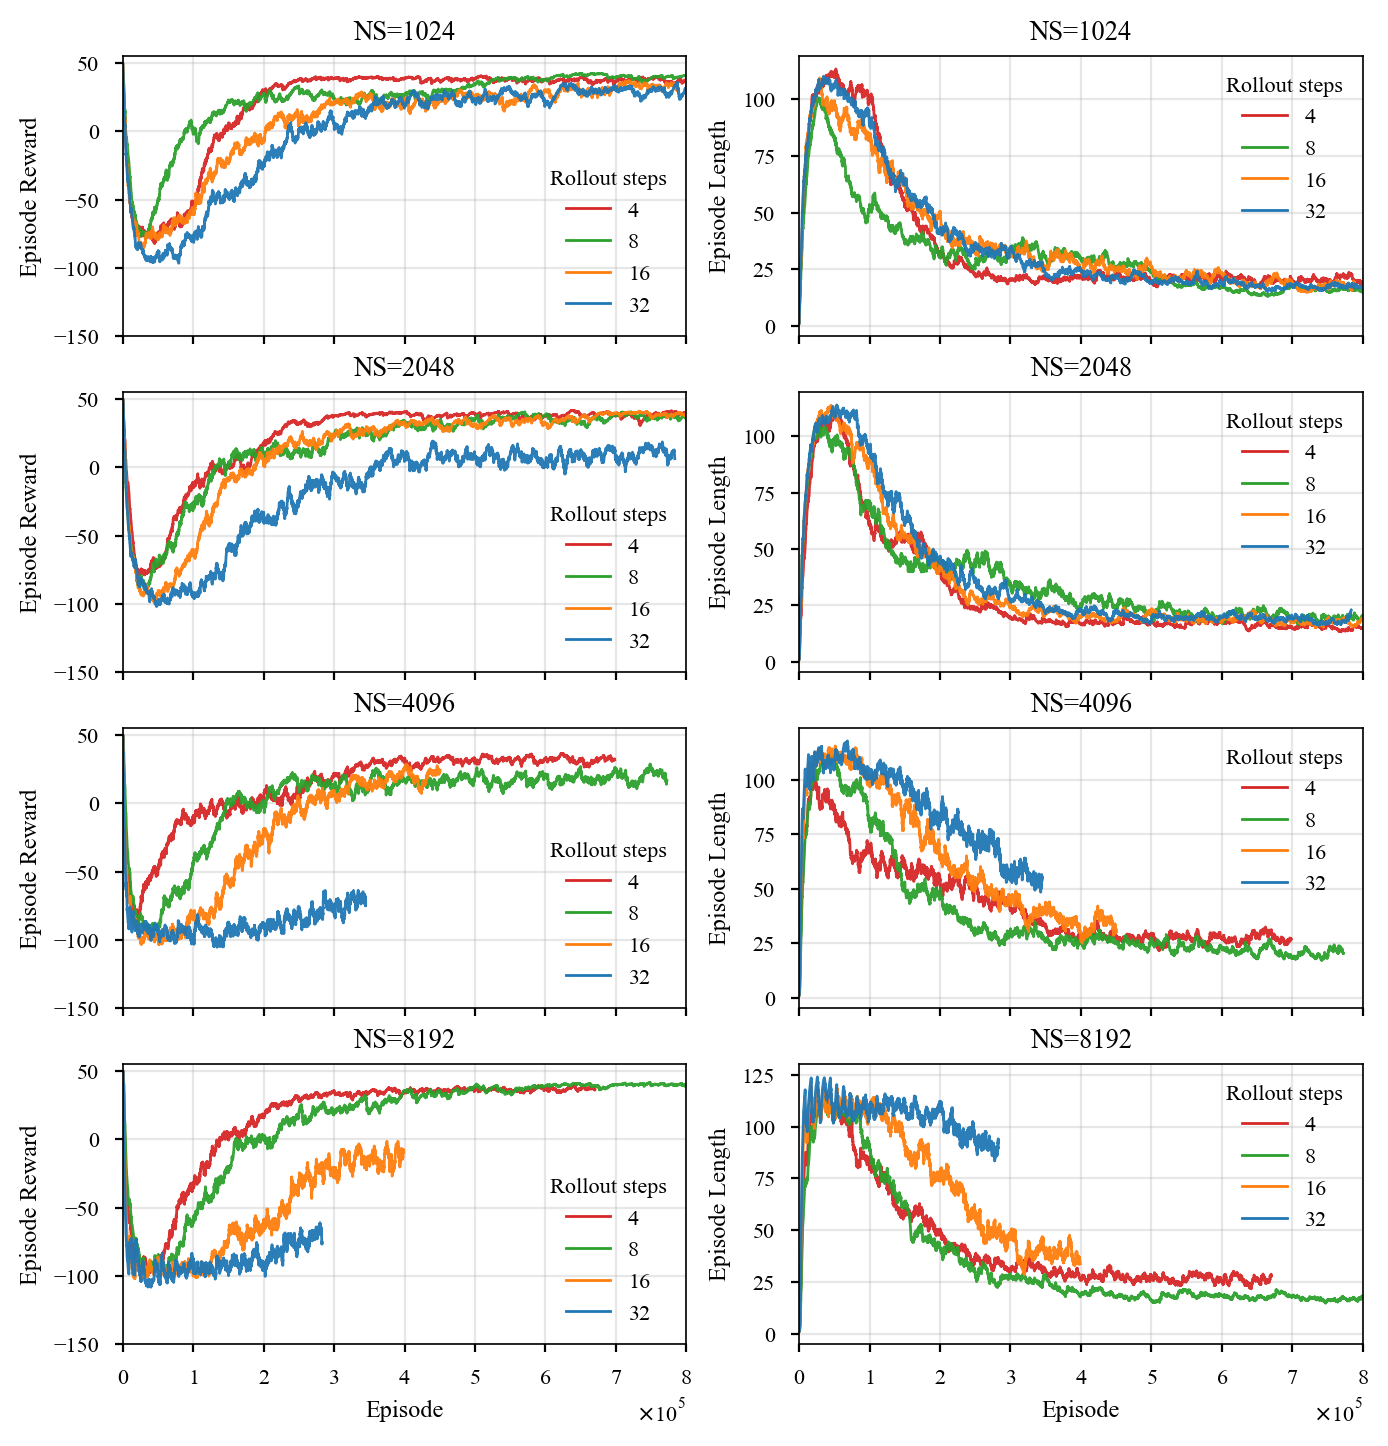

In [33]:
nrows, ncols = 4, 2

(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.20,
    hspace=0.20,
)

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False)
    
    num_bubbles = 1024
    for row in range(4):
        data = logs_B2_[logs_B2_.num_envs==num_bubbles]

        plot_log(
            data,
            tag="charts/episode_return",
            rollout_steps=[4, 8, 16, 32],
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 0],
            ylabel="Episode Reward",
            xlabel="Episode" if row==3 else " ",
            title=f"NS={num_bubbles}",
            ylim=(-150, 55)
        )

        axes[row, 0].set_xlim(0, int(8e5))

        plot_log(
            data,
            tag="charts/episode_length",
            rollout_steps=[4, 8, 16, 32],
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 1],
            ylabel="Episode Length",
            xlabel="Episode" if row==3 else " ",
            title=f"NS={num_bubbles}",
        )

        axes[row, 1].set_xlim(0, int(8e5))
        num_bubbles = num_bubbles*2

fig.subplots_adjust(**adj)
fig.savefig("figs/b2_episode_reward_and_length.pdf", bbox_inches="tight")
fig.savefig("figs/b2_episode_reward_and_length.png", dpi=300, bbox_inches="tight")
plt.show()

## Training time

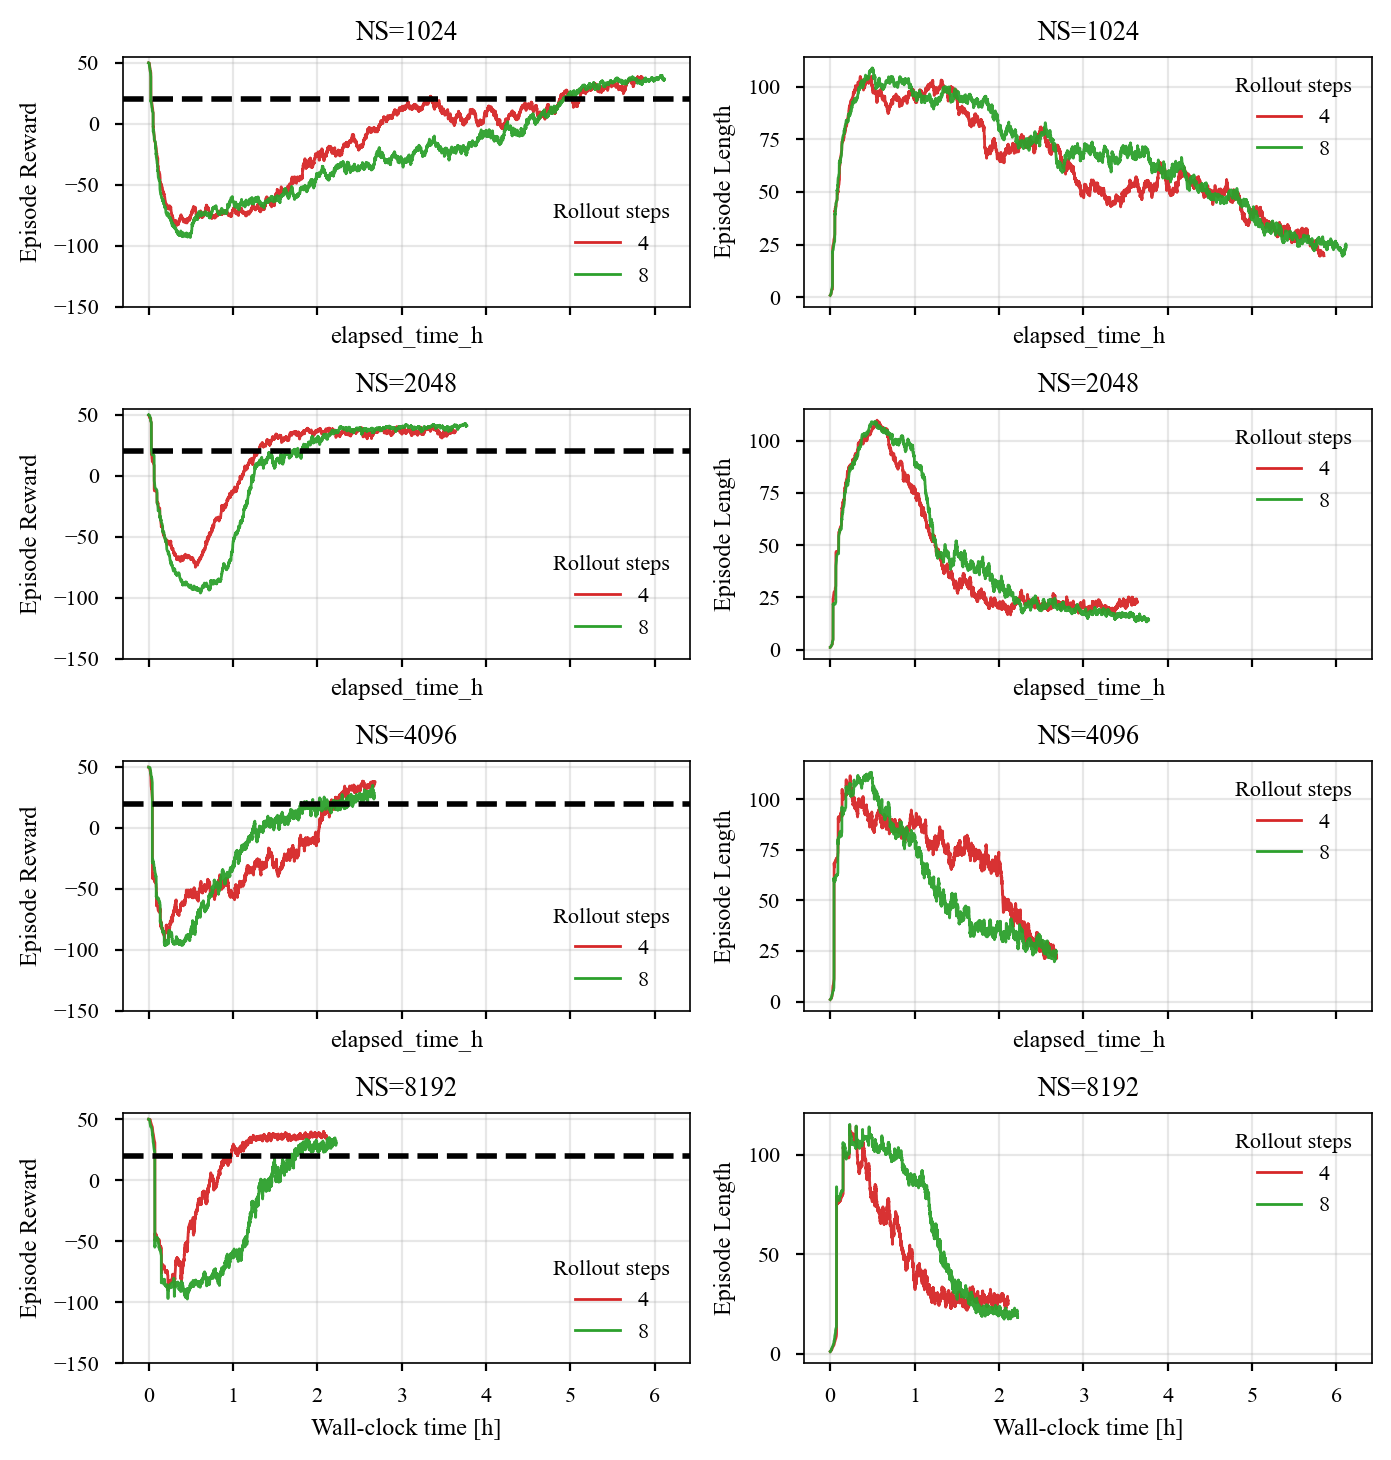

In [93]:
nrows, ncols = 4, 2

(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.20,
    hspace=0.20,
)

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False)
    
    num_bubbles = 1024
    for row in range(4):
        data = gcp_logs_B2_[gcp_logs_B2_.num_envs==num_bubbles]

        plot_log(
            data,
            tag="charts/episode_return",
            rollout_steps=[4, 8, 16, 32],
            x_col="elapsed_time_h",
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 0],
            ylabel="Episode Reward",
            xlabel="Wall-clock time [h]" if row==3 else "",
            title=f"NS={num_bubbles}",
            ylim=(-150, 55)
        )

        axes[row, 0].axhline(20, linestyle="--", linewidth=2, color="black")

        plot_log(
            data,
            tag="charts/episode_length",
            rollout_steps=[4, 8, 16, 32],
            x_col="elapsed_time_h",
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 1],
            ylabel="Episode Length",
            xlabel="Wall-clock time [h]" if row==3 else "",
            title=f"NS={num_bubbles}",
        )

        num_bubbles = num_bubbles*2


#fig.savefig("b2_episode_reward_and_length_time.pdf", bbox_inches="tight")
#fig.savefig("b2_episode_reward_and_length_time.png", dpi=300, bbox_inches="tight")
plt.show()

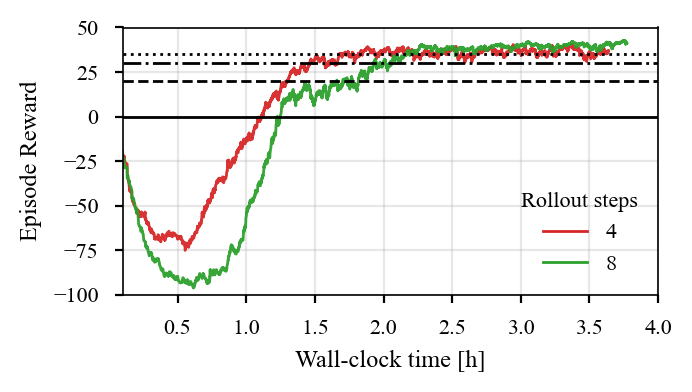

In [135]:
figsize = (3.5, 2.0)
num_envs = 2048
THRESHOLD_LINESTYLES = {
    0:  "-",
    20: "--",
    30: "-.",
    35: ":",
}

with plt.style.context("seaborn-v0_8-paper"):
    fig = plt.figure(figsize=figsize)
    ax = fig.gca()
    data = gcp_logs_B2_[gcp_logs_B2_.num_envs==num_envs]

    plot_log(
        data,
        tag="charts/episode_return",
        rollout_steps=[4, 8],
        x_col="elapsed_time_h",
        show_raw=False,
        smoothing=0.99,
        smoothed_line_width=1,
        ax=ax,
        ylabel="Episode Reward",
        xlabel="Wall-clock time [h]" if row==3 else "",
        title=None,
        ylim=(-100, 50)
    )

    ax.set_xlim(0.1, 4)
    ax.set_title("")
    ax.axhline(0, color="k", linestyle=THRESHOLD_LINESTYLES[0], linewidth=1)
    ax.axhline(20, color="k", linestyle=THRESHOLD_LINESTYLES[20], linewidth=1)
    ax.axhline(30, color="k", linestyle=THRESHOLD_LINESTYLES[30], linewidth=1)
    ax.axhline(35, color="k", linestyle=THRESHOLD_LINESTYLES[35], linewidth=1)

    
fig.tight_layout()
fig.savefig("figs/b2_train_time_NS_2048.pdf", bbox_inches="tight")
fig.savefig("figs/b2_train_time_NS_2048.png", dpi=300, bbox_inches="tight")
plt.show()


In [139]:
runs_B2_stats["num_envs"] = runs_B2_stats["num_envs"].astype(int)
runs_B2_stats["rollout_steps"] = runs_B2_stats["rollout_steps"].astype(int)
runs_B2_stats.columns

Index(['run', 'tb_log', 'stat_file', 'has_stat', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims',
       'success_rate', 'timeout_rate', 'failure_rate', 'success_ep_len_mean',
       'success_ep_len_std', 'success_ep_return_mean', 'success_ep_return_std',
       'ep_len_mean', 'ep_len_std', 'ep_len_ci', 'ep_return_mean',
       'ep_return_std', 'ep_return_ci', 'success_ep_len_ci',
       'success_ep_return_ci'],
      dtype='object')

In [140]:
gcp_runs_B2_stats["num_envs"] = gcp_runs_B2_stats["num_envs"].astype(int)
gcp_runs_B2_stats["rollout_steps"] = gcp_runs_B2_stats["rollout_steps"].astype(int)
gcp_runs_B2_stats.columns

Index(['run_id', 'tb_log', 'stat_file', 'has_stat', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims',
       'success_rate', 'timeout_rate', 'failure_rate', 'success_ep_len_mean',
       'success_ep_len_std', 'success_ep_return_mean', 'success_ep_return_std',
       'ep_len_mean', 'ep_len_std', 'ep_len_ci', 'ep_return_mean',
       'ep_return_std', 'ep_return_ci', 'success_ep_len_ci',
       'success_ep_return_ci'],
      dtype='object')

## Metrics

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Episode reward'}, xlabel='Number of parallel environments', ylabel='Episode reward'>)

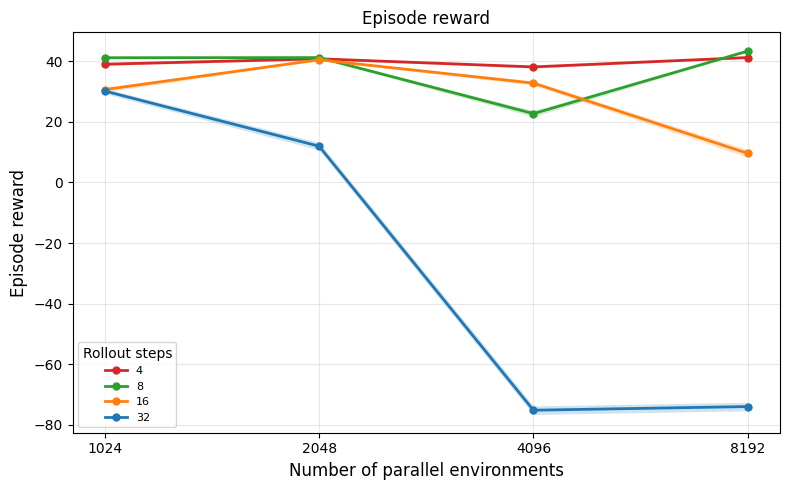

In [247]:
plot_metrics(
    runs_B2_stats[runs_B2_stats["num_envs"].isin([1024, 2048, 4096, 8192])],
    metric="ep_return",
    rollout_steps=[4, 8, 16, 32],
)

C:\Users\Kalman\AppData\Local\Temp\ipykernel_8456\1474632933.py:151: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


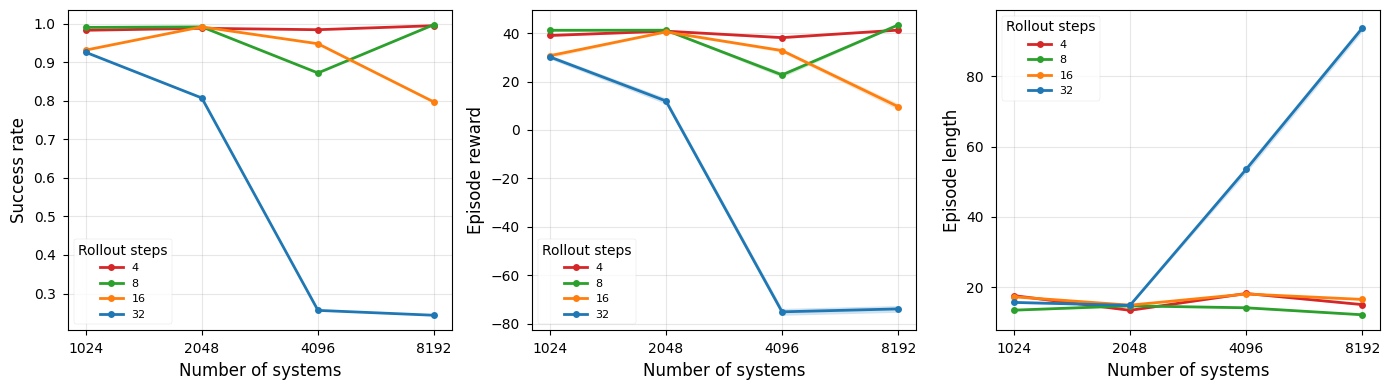

In [252]:
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        1, 3,
        figsize=(14, 4),
        sharex=True,
        constrained_layout=True)
    
    data = runs_B2_stats[runs_B2_stats["num_envs"].isin([1024, 2048, 4096, 8192])]

    plot_metrics(
        data,
        metric="success_rate",
        rollout_steps=[4, 8, 16, 32],
        ax=axes[0],
        title="",
        xlabel="Number of systems"
    )

    plot_metrics(
        data,
        metric="ep_return",
        rollout_steps=[4, 8, 16, 32],
        ax=axes[1],
        title="",
        xlabel="Number of systems"
    )

    plot_metrics(
        data,
        metric="ep_len",
        rollout_steps=[4, 8, 16, 32],
        ax=axes[2],
        title="",
        xlabel="Number of systems"
    )


fig.savefig("fig_B2_eval.pdf", bbox_inches="tight")
fig.savefig("fig_B2_eval.png", dpi=300, bbox_inches="tight")
plt.show()

## Time-To-Reward

In [100]:
def compute_time_to_reward(
    tb_log,
    reward_threshold=35.0,
    run_col="run_id",
    tag_col="tag",
    value_col="value",
    x_time_col="elapsed_time_h",
    step_col="step",
    reward_tag="charts/episode_return",
    smoothing=0.95,
    min_elapsed_h=0.1,
    n_consecutive=20,
):
    rows = []

    df = tb_log[tb_log[tag_col] == reward_tag].copy()
    df = df.sort_values([run_col, step_col])

    for run_id, g in df.groupby(run_col):
        g = g.sort_values(step_col).copy()

        g["reward_smooth"] = tensorboard_smooth(
            g[value_col].to_numpy(dtype=float),
            smoothing=smoothing,
        )

        g = g[g[x_time_col] >= min_elapsed_h].copy()

        above = g["reward_smooth"] >= reward_threshold
        sustained = above.rolling(n_consecutive).sum() >= n_consecutive

        if not sustained.any():
            first = None
        else:
            idx_end = sustained[sustained].index[0]
            pos_end = g.index.get_loc(idx_end)
            pos_start = pos_end - n_consecutive + 1
            first = g.iloc[pos_start]

        rows.append({
            run_col: run_id,
            "reward_threshold": reward_threshold,
            "time_to_reward_h": np.nan if first is None else first[x_time_col],
            "step_to_reward": np.nan if first is None else first[step_col],
            "reached_reward": first is not None,
        })

    return pd.DataFrame(rows)

In [101]:
def compute_time_to_reward_multi(
    tb_log,
    thresholds=(0, 20, 30, 35),
    **kwargs,
):
    dfs = []

    for threshold in thresholds:
        tmp = compute_time_to_reward(
            tb_log,
            reward_threshold=threshold,
            **kwargs,
        )
        tmp["threshold"] = threshold
        dfs.append(tmp)

    return pd.concat(dfs, ignore_index=True)

In [104]:
ttr_df = compute_time_to_reward_multi(
    gcp_logs_B2_,
    thresholds=[0, 20, 30, 35],
    x_time_col="elapsed_time_h",
    smoothing=0.95,
    min_elapsed_h=0.1,
    n_consecutive=20,
)

In [147]:
runs_B2_stats.rename(columns={"run": "run_id"}, inplace=True)

In [141]:
gcp_runs_B2_stats.rename(columns={"run": "run_id"}, inplace=True)


In [107]:
config_cols = ["run_id", "num_envs", "rollout_steps"]

ttr_df = ttr_df.merge(
    gcp_runs_B2_stats[config_cols],
    on="run_id",
    how="left",
)

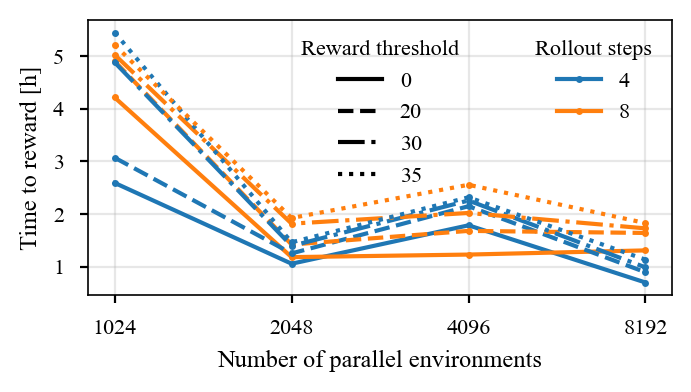

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


# Szín: rollout_steps
ROLLOUT_COLORS = {
    4: "tab:blue",
    8: "tab:orange",
}

# Vonaltípus: reward threshold
THRESHOLD_LINESTYLES = {
    0:  "-",
    20: "--",
    30: "-.",
    35: ":",
}


# A df helyére írd a saját DataFrame-ed változónevét
plot_df = (
    ttr_df.loc[ttr_df["reached_reward"]]
    .dropna(
        subset=[
            "num_envs",
            "rollout_steps",
            "threshold",
            "time_to_reward_h",
        ]
    )
    .copy()
)

plot_df["num_envs"] = plot_df["num_envs"].astype(int)
plot_df["rollout_steps"] = plot_df["rollout_steps"].astype(int)

# Több seed/run esetén automatikusan átlagol
plot_df = (
    plot_df
    .groupby(
        ["threshold", "rollout_steps", "num_envs"],
        as_index=False,
    )
    .agg(
        time_to_reward_h=("time_to_reward_h", "mean"),
        time_std_h=("time_to_reward_h", "std"),
        n_runs=("time_to_reward_h", "size"),
    )
    .sort_values(
        ["threshold", "rollout_steps", "num_envs"]
    )
)


with plt.style.context("seaborn-v0_8-paper"):
    fig, ax = plt.subplots(figsize=(3.5, 2.0))

    for (threshold, rollout), group in plot_df.groupby(
        ["threshold", "rollout_steps"],
        sort=True):

        group = group.sort_values("num_envs")

        color = ROLLOUT_COLORS.get(rollout)
        linestyle = THRESHOLD_LINESTYLES.get(threshold, "-")

        ax.plot(
            group["num_envs"],
            group["time_to_reward_h"],
            color=color,
            linestyle=linestyle,
            marker="o",
            linewidth=1.5,
            markersize=2.5,
        )

    # A num_envs értékek kétszereződnek, ezért célszerű a log2 tengely
    env_values = np.sort(plot_df["num_envs"].unique())

    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_locator(
        mticker.FixedLocator(env_values)
    )
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{int(x):d}")
    )
    ax.xaxis.set_minor_locator(mticker.NullLocator())

    ax.set_xlabel("Number of parallel environments")
    ax.set_ylabel("Time to reward [h]")

    ax.grid(
        True,
        which="major",
        alpha=0.3,
    )

    # Külön legend a színekhez
    rollout_handles = [
        Line2D(
            [0],
            [0],
            color=ROLLOUT_COLORS.get(rollout, "black"),
            marker="o",
            linestyle="-",
            linewidth=1.5,
            markersize=2.5,
            label=f"{rollout}",
        )
        for rollout in sorted(plot_df["rollout_steps"].unique())
    ]

    rollout_legend = ax.legend(
        handles=rollout_handles,
        title="Rollout steps",
        loc="upper right",
    )
    ax.add_artist(rollout_legend)

    # Külön legend a vonaltípusokhoz
    threshold_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle=THRESHOLD_LINESTYLES.get(threshold, "-"),
            linewidth=1.5,
            label=f"{threshold}",
        )
        for threshold in sorted(plot_df["threshold"].unique())
    ]

    ax.legend(
        handles=threshold_handles,
        title="Reward threshold",
        loc="upper center",
    )

    fig.tight_layout()

fig.savefig("figs/b2_time_to_reward.pdf", bbox_inches="tight")
fig.savefig("figs/b2_time_to_reward.png", dpi=300, bbox_inches="tight")
plt.show()

## DPS

In [168]:
dps_df = logs_B2_[logs_B2_["tag"] == "perf/DPS"].copy()

dps_summary = (
    dps_df
    .groupby("run_id")
    .agg(
        dps_mean=("value", "mean"),
        dps_median=("value", "median"),
        dps_std=("value", "std"),
    )
    .reset_index()
)

dps_summary = dps_summary.merge(
    runs_B2_stats[["run_id", "num_envs", "rollout_steps"]],
    on="run_id",
    how="left",
)

In [169]:
gcp_dps_df = gcp_logs_B2_[gcp_logs_B2_["tag"] == "perf/DPS"].copy()

gcp_dps_summary = (
    gcp_dps_df
    .groupby("run_id")
    .agg(
        dps_mean=("value", "mean"),
        dps_median=("value", "median"),
        dps_std=("value", "std"),
    )
    .reset_index()
)

gcp_dps_summary = gcp_dps_summary.merge(
    gcp_runs_B2_stats[["run_id", "num_envs", "rollout_steps"]],
    on="run_id",
    how="left",
)

In [150]:
def summarize_perf_times(
    tb_log,
    run_col="run_id",
    tag_col="tag",
    value_col="value",
    warmup_h=None,
    time_col="elapsed_time_h",
):
    df = tb_log.copy()

    if warmup_h is not None:
        df = df[df[time_col] >= warmup_h]

    train = (
        df[df[tag_col] == "perf/training_time"]
        .groupby(run_col)[value_col]
        .median()
        .rename("training_time_median")
    )

    sample = (
        df[df[tag_col] == "perf/sampling_time"]
        .groupby(run_col)[value_col]
        .median()
        .rename("sampling_time_median")
    )

    out = pd.concat([train, sample], axis=1).reset_index()

    out["total_time_median"] = (
        out["training_time_median"] + out["sampling_time_median"]
    )
    out["sampling_fraction"] = (
        out["sampling_time_median"] / out["total_time_median"]
    )
    out["training_fraction"] = (
        out["training_time_median"] / out["total_time_median"]
    )

    return out

In [173]:
df_gtx1070 = summarize_perf_times(
    logs_B2_,
    warmup_h=0.05,
)

df_gtx1070 = df_gtx1070.merge(
    dps_summary,
    on="run_id",
    how="left",
)

In [175]:
df_p100 = summarize_perf_times(
    gcp_logs_B2_,
    warmup_h=0.05,
)

df_p100 = df_p100.merge(
    gcp_dps_summary,
    on="run_id",
    how="left",
)

In [155]:
def any_plot(
    df_plot,
    rollout_steps,
    plot_col: str = "dps_mean",
    figsize=(8.0, 5.0),
    line_width=2.0,
    marker="o",
    marker_size=5.0,
    log_x=True,
    ylim=None,
    title=None,
    xlabel="Number of parallel environments",
    ylabel=None,
    ax = None
):
    
    cols = set(df_plot.columns)
    if plot_col not in cols:
        raise ValueError(f"Unknown plot_col: {plot_col}. Available: {cols}")
    
    df = df_plot.copy()
    df["rollout_steps"] = df["rollout_steps"].astype(int)

    if rollout_steps is not None:
        if isinstance(rollout_steps, (int, float, str)):
            rollout_steps = [rollout_steps]

        rollout_steps = [int(r) for r in rollout_steps]
        df = df[df["rollout_steps"].isin(rollout_steps)]

    if df.empty:
        raise ValueError("No data after filtering.")

    df = df.sort_values(["rollout_steps", "num_envs"])

    rollouts = sorted(df["rollout_steps"].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for rollout in rollouts:
        g = df[df["rollout_steps"] == rollout].copy()
        g = g.sort_values("num_envs")

        x = g["num_envs"]
        y = g[plot_col]

        color = COLOR_MAP.get(rollout, None)

        ax.plot(
            x,
            y,
            color=color,
            linewidth=line_width,
            marker=marker,
            markersize=marker_size,
            label=f"{rollout}",
        )

    if log_x:
        ax.set_xscale("log", base=2)

        xticks = sorted(df["num_envs"].dropna().unique())
        ax.set_xticks(xticks)

        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{int(x):d}")
        )
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if ylim is not None:
        ax.set_ylim(*ylim)
    

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel or plot_col, fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

    if title is None:
        title = plot_col

    ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", alpha=0.3)

    ax.legend(
        title="Rollout steps",
        loc="best",
        fontsize=8,
        title_fontsize=10,
    )

    fig.tight_layout()

    return fig, ax



C:\Users\Kalman\AppData\Local\Temp\ipykernel_7484\1070253246.py:94: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


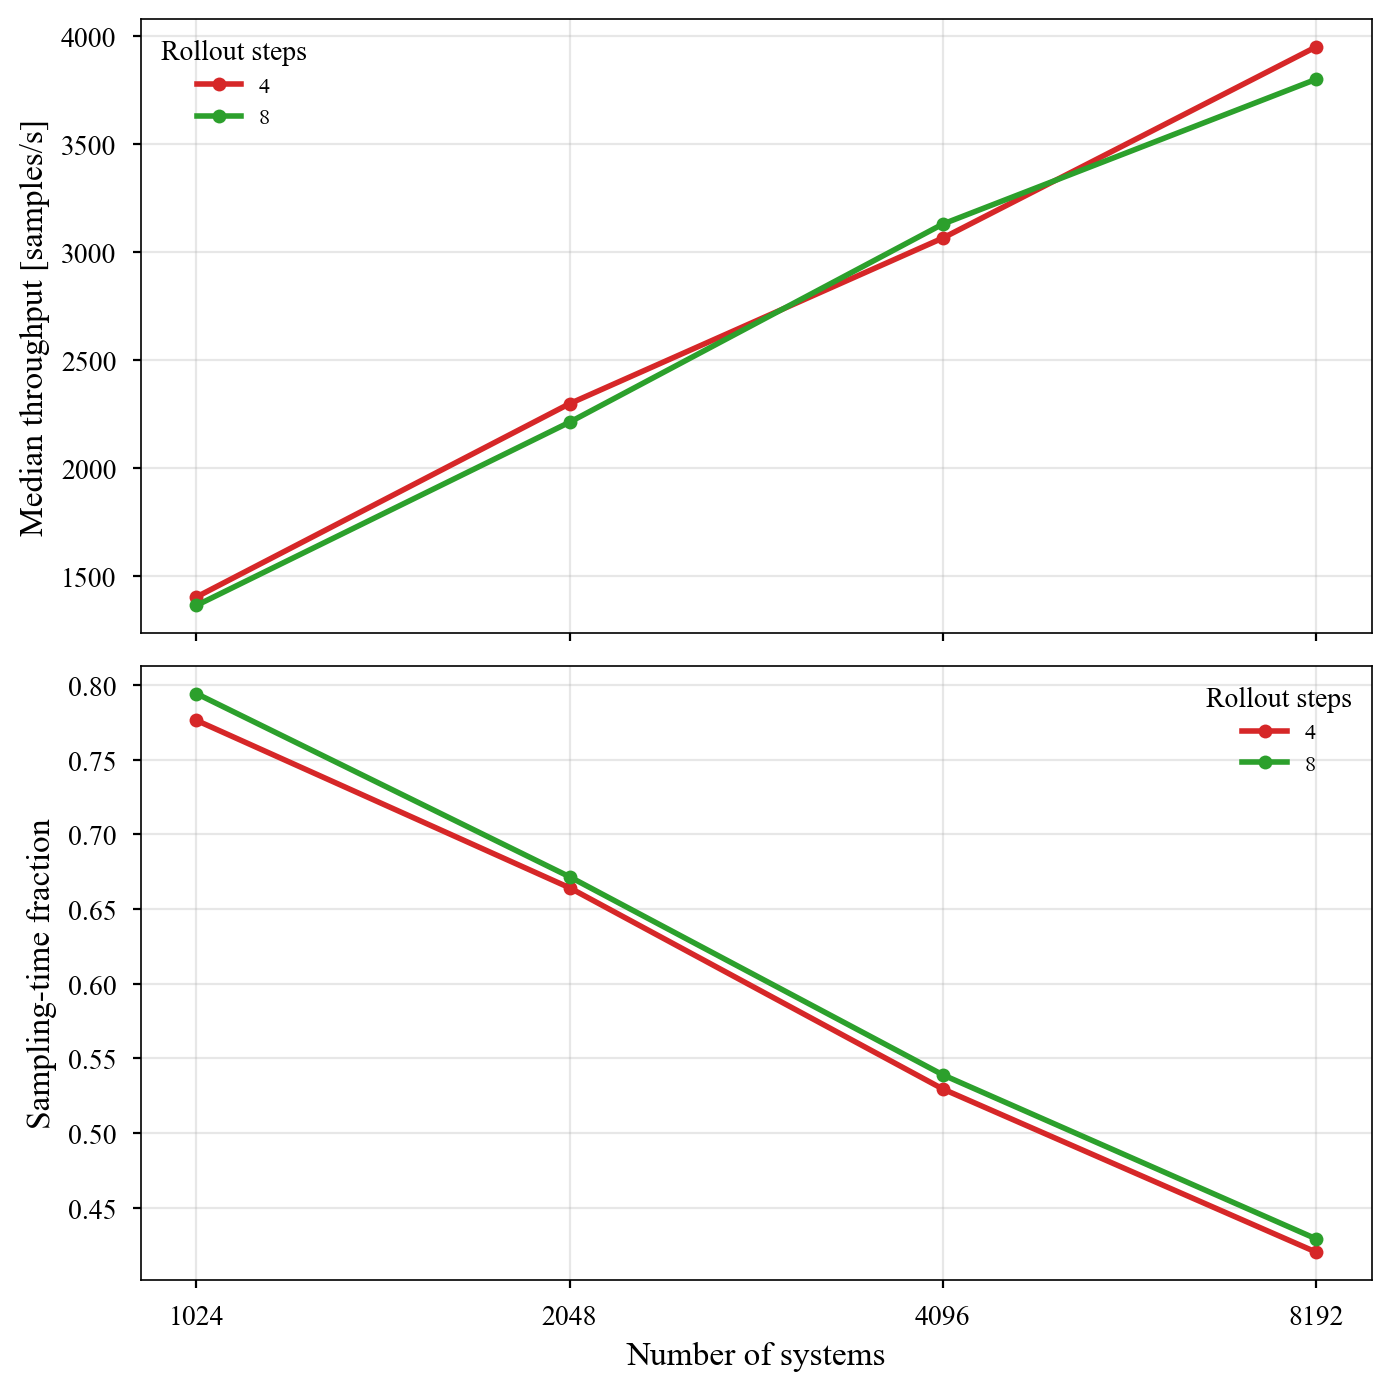

In [177]:
with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        2, 1,
        figsize=(7, 7),
        sharex=True,
        constrained_layout=True,
    )


    any_plot(
        df_p100[df_p100["num_envs"].isin([1024, 2048, 4096, 8192])],
        rollout_steps=[4, 8, 16, 32],
        plot_col="dps_median",
        xlabel="Number of systems",
        ylabel="Median throughput [samples/s]",
        ax=axes[0],
        title=""
    )
    
    axes[0].set_xlabel("")

    any_plot(
        df_p100[df_p100["num_envs"].isin([1024, 2048, 4096, 8192])],
        rollout_steps=[4, 8, 16, 32],
        plot_col="sampling_fraction",
        xlabel="Number of systems",
        ylabel="Sampling-time fraction",
        ax=axes[1],
        title=""
    )


    fig.savefig("figs/fig_train_perf.pdf", bbox_inches="tight")
    fig.savefig("figs/fig_train_perf.png", dpi=300, bbox_inches="tight")
    plt.show()

C:\Users\Kalman\AppData\Local\Temp\ipykernel_7484\4253769518.py:255: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(**adj)


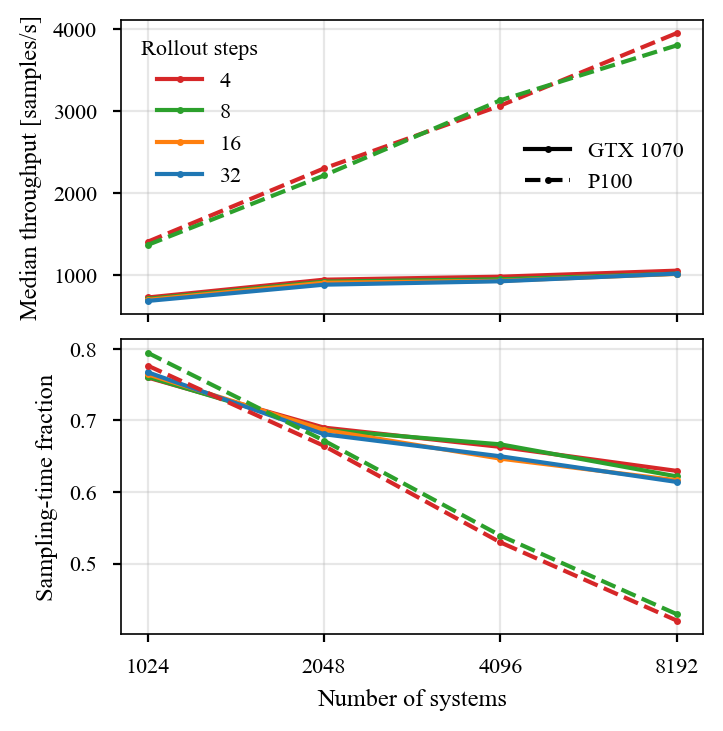

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


COLOR_MAP = {
    32: "tab:blue",
    16: "tab:orange",
    8:  "tab:green",
    4:  "tab:red",
}

GPU_LINESTYLES = {
    "GTX 1070": "-",
    "P100": "--",
}

ENV_VALUES = [1024, 2048, 4096, 8192]


# ------------------------------------------------------------------
# GTX 1070 és P100 adatok közös DataFrame-be
# ------------------------------------------------------------------

plot_df = pd.concat(
    [
        df_gtx1070.assign(gpu="GTX 1070"),
        df_p100.assign(gpu="P100"),
    ],
    ignore_index=True,
)

required_columns = {
    "num_envs",
    "rollout_steps",
    "dps_median",
    "sampling_fraction",
}

missing = required_columns - set(plot_df.columns)

if missing:
    raise ValueError(
        f"Missing columns: {sorted(missing)}\n"
        f"Available columns: {sorted(plot_df.columns)}"
    )

plot_df["num_envs"] = pd.to_numeric(
    plot_df["num_envs"],
    errors="coerce",
)

plot_df["rollout_steps"] = pd.to_numeric(
    plot_df["rollout_steps"],
    errors="coerce",
)

plot_df["dps_median"] = pd.to_numeric(
    plot_df["dps_median"],
    errors="coerce",
)

plot_df["sampling_fraction"] = pd.to_numeric(
    plot_df["sampling_fraction"],
    errors="coerce",
)

plot_df = plot_df[
    plot_df["num_envs"].isin(ENV_VALUES)
].copy()

plot_df = plot_df.dropna(
    subset=["num_envs", "rollout_steps", "gpu"]
)

plot_df["num_envs"] = plot_df["num_envs"].astype(int)
plot_df["rollout_steps"] = plot_df["rollout_steps"].astype(int)


# Ha egy konfigurációhoz több sor tartozik, átlagoljuk őket.
plot_df = (
    plot_df
    .groupby(
        ["gpu", "rollout_steps", "num_envs"],
        as_index=False,
    )
    .agg(
        dps_median=("dps_median", "mean"),
        sampling_fraction=("sampling_fraction", "mean"),
    )
    .sort_values(
        ["gpu", "rollout_steps", "num_envs"]
    )
)


# ------------------------------------------------------------------
# Ábra
# ------------------------------------------------------------------

(width, height), adj = pu.two_column_figsize(2, 1, width_in=3.5, panel_height_in=1.2, hspace=0.2)

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(width, height),
        sharex=True,
        constrained_layout=True,
    )

    plot_settings = [
        (
            axes[0],
            "dps_median",
            "Median throughput [samples/s]",
        ),
        (
            axes[1],
            "sampling_fraction",
            "Sampling-time fraction",
        ),
    ]

    for ax, plot_col, ylabel in plot_settings:

        metric_df = plot_df.dropna(
            subset=[plot_col]
        )

        # Csak a ténylegesen létező GPU–rollout kombinációkat járjuk be.
        # Emiatt nem probléma, hogy P100-on nincs rollout=16 és 32.
        for (gpu, rollout), group in metric_df.groupby(
            ["gpu", "rollout_steps"],
            sort=True,
        ):
            group = group.sort_values("num_envs")

            ax.plot(
                group["num_envs"],
                group[plot_col],
                color=COLOR_MAP.get(rollout, "black"),
                linestyle=GPU_LINESTYLES.get(gpu, "-"),
                linewidth=1.5,
                marker="o",
                markersize=2.5,
            )

        ax.set_ylabel(ylabel)
        ax.grid(
            True,
            which="major",
            alpha=0.3,
        )

    axes[0].set_xlabel("")
    axes[1].set_xlabel("Number of systems")


    # ------------------------------------------------------------------
    # Log2 x-tengely, csak a tényleges num_envs értékekkel
    # ------------------------------------------------------------------

    axes[1].set_xscale("log", base=2)
    axes[1].xaxis.set_major_locator(
        mticker.FixedLocator(ENV_VALUES)
    )
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, pos: f"{int(x):d}"
        )
    )
    axes[1].xaxis.set_minor_locator(
        mticker.NullLocator()
    )
    axes[1].xaxis.set_minor_formatter(
        mticker.NullFormatter()
    )


    # ------------------------------------------------------------------
    # Külön legend: rollout = szín
    # ------------------------------------------------------------------

    available_rollouts = sorted(
        plot_df["rollout_steps"].unique()
    )

    rollout_handles = [
        Line2D(
            [0],
            [0],
            color=COLOR_MAP.get(rollout, "black"),
            linestyle="-",
            linewidth=1.5,
            marker="o",
            markersize=2.5,
            label=f"{rollout}",
        )
        for rollout in available_rollouts
    ]

    rollout_legend = axes[0].legend(
        handles=rollout_handles,
        title="Rollout steps",
        loc="upper left",
    )

    axes[0].add_artist(rollout_legend)


    # ------------------------------------------------------------------
    # Külön legend: GPU = vonaltípus
    # ------------------------------------------------------------------

    available_gpus = [
        gpu
        for gpu in GPU_LINESTYLES
        if gpu in plot_df["gpu"].unique()
    ]

    gpu_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle=GPU_LINESTYLES[gpu],
            linewidth=1.5,
            marker="o",
            markersize=2.5,
            label=gpu,
        )
        for gpu in available_gpus
    ]

    axes[0].legend(
        handles=gpu_handles,
        #title="GPU",
        loc="center right",
    )


    fig.savefig(
        "figs/fig_train_perf_gpu_comparison.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        "figs/fig_train_perf_gpu_comparison.png",
        dpi=300,
        bbox_inches="tight",
    )

fig.subplots_adjust(**adj)
fig.savefig("figs/gpu_perf_comparison.pdf", bbox_inches="tight")
fig.savefig("figs/gpu_perf_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 3 & 4 Bubbles

In [34]:
bubble_3_runs = [
    "PA_PS_Control_b3_epb32_ne2048_id1783926598",
    "PA_PS_Control_b3_epb32_ne4096_id1784094853",
    "PA_PS_Control_b3_epb32_ne8192_id1784239403"
]

bubble_4_runs = [
    "PA_PS_Control_b4_epb16_ne4096_id1779095563",
]

In [35]:
logs_B3 = list_tb_run_dirs(DISTANCE_CONTROL_3B)
runs_B3 = list_run_and_data(logs_B3, all_metrics, matched_only=True)
runs_B3.shape

(6, 4)

In [40]:
logs_B4 = list_tb_run_dirs(DISTANCE_CONTROL_4B)
runs_B4 = list_run_and_data(logs_B4, all_metrics, matched_only=True)
runs_B4.shape

(4, 4)

In [42]:
runs_B3_filtered = runs_B3[runs_B3.run.isin(bubble_3_runs)]
runs_B4_filtered = runs_B4[runs_B4.run.isin(bubble_4_runs)]

In [44]:
runs_B3_filtered, logs_B3 = read_all_logs(runs_B3_filtered)
runs_B3_stats = add_stats(runs_B3_filtered)

In [203]:
runs_B3_stats.columns

Index(['run', 'tb_log', 'stat_file', 'has_stat', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims',
       'success_rate', 'timeout_rate', 'failure_rate', 'success_ep_len_mean',
       'success_ep_len_std', 'success_ep_return_mean', 'success_ep_return_std',
       'ep_len_mean', 'ep_len_std', 'ep_len_ci', 'ep_return_mean',
       'ep_return_std', 'ep_return_ci', 'success_ep_len_ci',
       'success_ep_return_ci'],
      dtype='object')

In [43]:
runs_B4_filtered, logs_B4 = read_all_logs(runs_B4_filtered)
runs_B4_stats = add_stats(runs_B4_filtered)

In [48]:
logs_B3['num_envs'] = logs_B3['num_envs'].astype(int)
logs_B3['rollout_steps'] = logs_B3['rollout_steps'].astype(int)

logs_B4['num_envs'] = logs_B4['num_envs'].astype(int)
logs_B4['rollout_steps'] = logs_B4['rollout_steps'].astype(int)

In [52]:
logs_B3['num_envs'].unique()

array([2048, 4096, 8192])

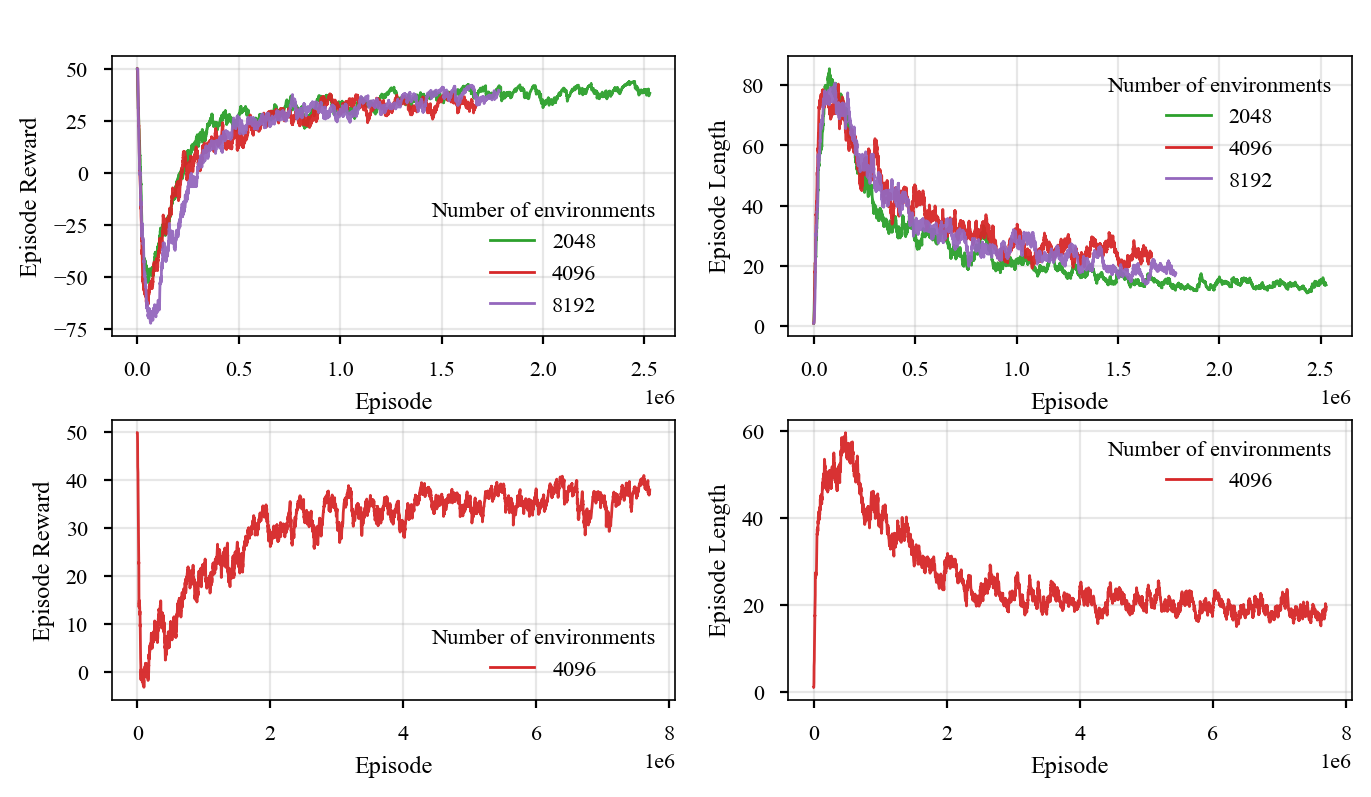

In [71]:
nrows, ncols = 2, 2
plot_data = [logs_B3, logs_B4]


(fig_w, fig_h), adj = pu.two_column_figsize(
    nrows, ncols,
    width_in=7.0,
    panel_height_in=1.40,
    wspace=0.20,
    hspace=0.30,
)

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=False, sharey=False)
    
    num_bubbles = 3
    for row in range(2):
        #data = logs_B2_[logs_B2_.num_envs==num_bubbles]
        data = plot_data[row]

        plot_log_by_env(
            data,
            tag="charts/episode_return",
            rollout_steps=8,
            envs=[2048, 4096, 8192],
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 0],
            ylabel="Episode Reward",
            xlabel="Episode",
            title=f" ",
            #ylim=(-150, 55)
        )

        #axes[row, 0].set_xlim(0, int(8e5))

        plot_log_by_env(
            data,
            tag="charts/episode_length",
            rollout_steps=8,
            envs=[2048, 4096, 8192],
            show_raw=False,
            smoothing=0.99,
            smoothed_line_width=1,
            ax=axes[row, 1],
            ylabel="Episode Length",
            xlabel="Episode",
            title=f" ",
        )

        #axes[row, 1].set_xlim(0, int(8e5))
        num_bubbles = num_bubbles + 1

fig.subplots_adjust(**adj)
fig.savefig("figs/b34_episode_reward_and_length.pdf", bbox_inches="tight")
fig.savefig("figs/b34_episode_reward_and_length.png", dpi=300, bbox_inches="tight")
plt.show()

# Stats

In [189]:
runs_B2_stats.columns

Index(['run_id', 'tb_log', 'stat_file', 'has_stat', 'gamma', 'gae_lambda',
       'mini_batch_size', 'clip_coef', 'clip_vloss', 'ent_coef', 'vf_coef',
       'max_grad_norm', 'target_kl', 'norm_adv', 'num_envs', 'rollout_steps',
       'num_update_epochs', 'gradient_steps', 'seed', 'buffer_device',
       'policy_type', 'hidden_dims', 'activations', 'shared_dims',
       'success_rate', 'timeout_rate', 'failure_rate', 'success_ep_len_mean',
       'success_ep_len_std', 'success_ep_return_mean', 'success_ep_return_std',
       'ep_len_mean', 'ep_len_std', 'ep_len_ci', 'ep_return_mean',
       'ep_return_std', 'ep_return_ci', 'success_ep_len_ci',
       'success_ep_return_ci'],
      dtype='object')

In [211]:
runs_B3_stats["num_envs"] = runs_B3_stats["num_envs"].astype(int)
runs_B3_stats["rollout_steps"] = runs_B3_stats["rollout_steps"].astype(int)

runs_B4_stats["num_envs"] = runs_B4_stats["num_envs"].astype(int)
runs_B4_stats["rollout_steps"] = runs_B4_stats["rollout_steps"].astype(int)

In [196]:
runs_B2_stats.loc[
        runs_B2_stats["num_envs"] == 2048,
        ["rollout_steps", "success_rate", "timeout_rate", "failure_rate", "ep_len_mean", "ep_len_ci", "ep_return_mean", "ep_return_ci"],
    ].reset_index(drop=True)

,rollout_steps,success_rate,timeout_rate,failure_rate,ep_len_mean,ep_len_ci,ep_return_mean,ep_return_ci
0,32,0.807500,0.0,0.192500,14.816900,0.237492,11.972558,1.232386
1,16,0.992082,0.0,0.007918,14.883610,0.215353,40.483611,0.293963
2,8,0.992031,0.0,0.007969,14.688415,0.229323,41.194157,0.286187
3,4,0.988302,0.0,0.011698,13.413899,0.196752,40.802790,0.341721


In [213]:
runs_B3_stats.loc[
        runs_B3_stats["num_envs"] == 2048,
        ["rollout_steps", "success_rate", "timeout_rate", "failure_rate", "ep_len_mean", "ep_len_ci", "ep_return_mean", "ep_return_ci"],
    ].reset_index(drop=True)

,rollout_steps,success_rate,timeout_rate,failure_rate,ep_len_mean,ep_len_ci,ep_return_mean,ep_return_ci
0,8,0.96879,0.0,0.03121,10.686222,0.178782,40.246391,0.544616


In [214]:
runs_B4_stats.loc[
        runs_B4_stats["num_envs"] == 4096,
        ["rollout_steps", "success_rate", "timeout_rate", "failure_rate", "ep_len_mean", "ep_len_ci", "ep_return_mean", "ep_return_ci"],
    ].reset_index(drop=True)

,rollout_steps,success_rate,timeout_rate,failure_rate,ep_len_mean,ep_len_ci,ep_return_mean,ep_return_ci
0,8,0.975379,0.0,0.024621,9.257476,0.174676,42.043051,0.506996
